In [1]:
import math
import numpy as np
import os
import torch
import torch.nn as nn
from tqdm import tqdm
# from ..functions import discrete_klv2d, hist2d
# from ..utils import save_scatterplot
# from ..utils.train import DummyScheduler, RunningStatistics
import wandb
from matplotlib import pyplot as plt

import os
import torch
from ddpm_torch.toy import *
from ddpm_torch.utils import seed_all, infer_range
from torch.optim import Adam, lr_scheduler
from matplotlib import pyplot as plt
from argparse import ArgumentParser
import wandb

In [2]:
trainloader = DataStreamer("UnbalancedGaussian2D", batch_size=10000, num_batches=2, modes=2)
evaluator = Evaluator(
    true_data=np.concatenate([
        next(iter(trainloader)) for _ in range(2)
    ]), eval_batch_size=1000, max_eval_count=2000, value_range=[0, 10])

betas = get_beta_schedule(
    "linear", beta_start=0.001, beta_end=0.01, timesteps=1000)

diffusion = GaussianDiffusion(
    betas=betas, model_mean_type="eps", model_var_type="fixed-large", loss_type="mse")


def denoise_fn(x_t, t):
    return diffusion.get_true_score_unbalanced_gmm(x_t, t)


def sample_fn(n):
    shape = (n,) + (2,)
    sample = diffusion.p_sample_grad(
        denoise_fn=denoise_fn, shape=shape, device="cpu", noise=None)
    return sample.detach().cpu().numpy()

    # if evaluator is not None:


eval_results = evaluator.eval(sample_fn)
gen_data_langevin = eval_results['x_gen']

Timesteps: 1000


In [9]:
gen_data = np.load(f'{os.getcwd()}/chkpts/UnbalancedGaussian2D_200000_rssm_uniform_4/gen_dataset.npy')
np.random.shuffle(gen_data)

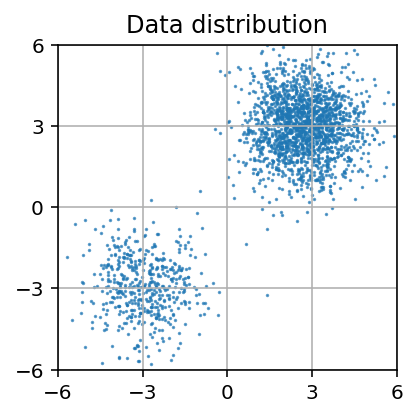

In [22]:
plt.figure(figsize=(3, 3))
plt.scatter(*np.hsplit(gen_data, 2), s=0.5, alpha=0.7)
plt.xlim([-6, 6])
plt.ylim([-6, 6])
plt.grid(True)
plt.xticks(np.array([-6, -3, 0, 3, 6]))
plt.yticks(np.array([-6, -3, 0, 3, 6]))
# plt.axis('equal')
plt.title(f'Data distribution')
plt.tight_layout()
plt.savefig('data.pdf')

(array([ 4882., 25118.]),
 array([-91646.7109375, -14983.8203125,  61679.078125 ]),
 <BarContainer object of 2 artists>)

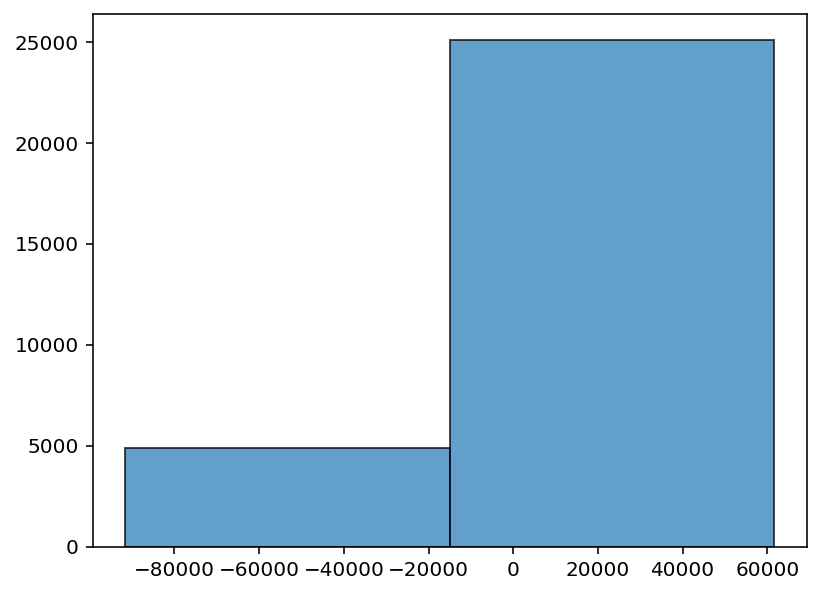

In [23]:
plt.hist(gen_data[:, 0], bins=2, alpha=0.7, edgecolor='black')

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

true_data = np.load(f'{os.getcwd()}/chkpts/UnbalancedGaussian2D_200000_rssm_Gaussian_0/real_dataset.npy')
def plot_hist(gen_data, title, fig_name, original_data=False,
              is_rssm:bool=False):
    np.random.shuffle(gen_data)
    gen_data = gen_data[:2000] if not is_rssm else gen_data
    
    if not original_data:
        # Estimate distributions using histograms
        bins = 50
        hist1, bin_edges = np.histogram(gen_data, bins=bins, density=True)
        hist2, _ = np.histogram(true_data, bins=bin_edges, density=True)
        
        # Avoid division by zero
        hist1 += 1e-10
        hist2 += 1e-10
        
        # Normalize histograms to get probabilities
        prob1 = hist1 / np.sum(hist1)
        prob2 = hist2 / np.sum(hist2)
        
        # Compute KL divergence
        kl_divergence = entropy(prob1, prob2)
        print("KL Divergence:", kl_divergence)

    plt.figure(figsize=(3, 3))
    # Generate example 2D data
    x = gen_data[:, 0]
    y = gen_data[:, 1]
    
    # Create the figure and gridspec layout
    fig = plt.figure(figsize=(3, 3))
    grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
    
    # Scatter plot
    scatter_ax = fig.add_subplot(grid[1:, :-1])
    scatter_ax.scatter(x, y, alpha=0.5, s=0.5)
    scatter_ax.set_xlim([-6, 6])
    scatter_ax.set_ylim([-6, 6])
    scatter_ax.set_xticks(np.array([-6, -3, 0, 3, 6]))
    scatter_ax.set_yticks(np.array([-6, -3, 0, 3, 6]))
    scatter_ax.grid(True)
    
    # Histogram for X-axis
    x_hist_ax = fig.add_subplot(grid[0, :-1], sharex=scatter_ax)
    counts, bins, patches = x_hist_ax.hist(x, bins=[-6, 0, 6], color='blue', alpha=0.7,weights=np.ones_like(x) / len(x))
    # x_hist_ax.axis('off')  # Hide x-ticks and labels
    x_hist_ax.grid(True)
    x_hist_ax.set_yticks([0.2, 0.8,])
    x_hist_ax.set_yticklabels(['20%', '80%'])
    x_hist_ax.tick_params(axis='x', which='both', labelbottom=False)
    
    # Add numbers to the bins
    for count, bin_edge in zip(counts, bins[:-1]):  # Exclude the last edge since bins have one extra
        bin_center = bin_edge + (bins[1] - bins[0]) / 2  # Calculate the center of the bin
        plt.text(bin_center, count-0.2, f'{count:.0%}', ha='center', va='bottom',color='white',fontsize=8)
    
    
    # Histogram for Y-axis
    y_hist_ax = fig.add_subplot(grid[1:, -1], sharey=scatter_ax)
    counts, bins, patches = y_hist_ax.hist(y, bins=[-6, 0, 6], orientation='horizontal', color='green', alpha=0.7,weights=np.ones_like(y) / len(y))
    y_hist_ax.grid(True)
    y_hist_ax.tick_params(axis='y', which='both', labelleft=False)
    y_hist_ax.set_xticks([0.2, 0.8])
    y_hist_ax.set_xticklabels(['20%', '80%'])
    
    # Add numbers to the bins
    for count, bin_edge in zip(counts, bins[:-1]):  # Exclude the last edge since bins have one extra
        bin_center = bin_edge + (bins[1] - bins[0]) / 2  # Calculate the center of the bin
        plt.text(count-0.1, bin_center, f'{count:.0%}', ha='center', va='bottom',color='black',fontsize=8)
    
    if not original_data:
        plt.suptitle(f"{title}\n KL Div to true data: {kl_divergence:.3f}", fontsize=10)
    else:
        plt.suptitle(title, fontsize=14)
    
    # Adjust the layout to avoid overlaps
    plt.tight_layout()
    
    # Show the plot
    plt.savefig(fig_name, dpi=300)



KL Divergence: 0.014661197354135142
KL Divergence: 10.172475496976881


C:\Users\7459985\AppData\Local\Temp\ipykernel_13016\1068029239.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\7459985\AppData\Local\Temp\ipykernel_13016\1068029239.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


KL Divergence: 9.607202063025621
KL Divergence: 0.07166546006357705


C:\Users\7459985\AppData\Local\Temp\ipykernel_13016\1068029239.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\7459985\AppData\Local\Temp\ipykernel_13016\1068029239.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\7459985\AppData\Local\Temp\ipykernel_13016\1068029239.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 432x432 with 0 Axes>

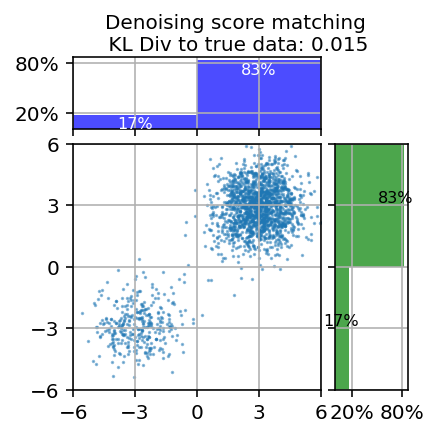

<Figure size 432x432 with 0 Axes>

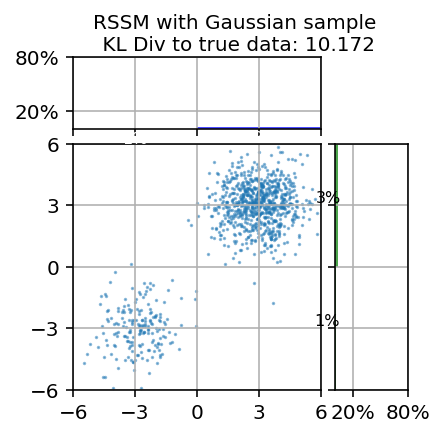

<Figure size 432x432 with 0 Axes>

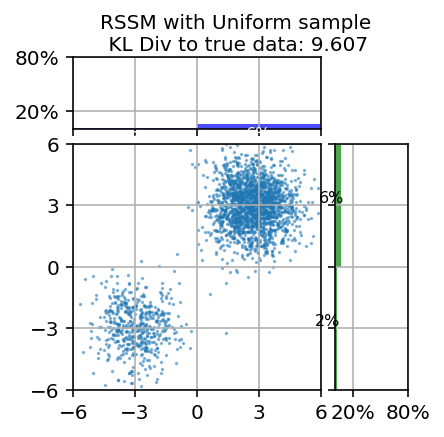

<Figure size 432x432 with 0 Axes>

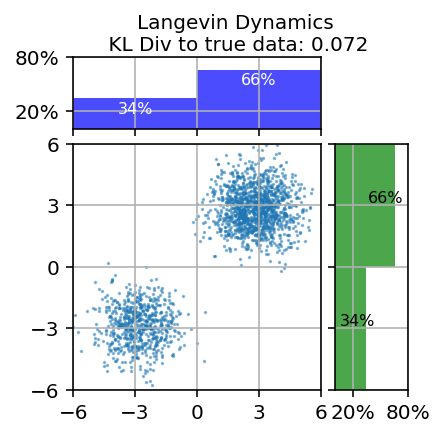

<Figure size 432x432 with 0 Axes>

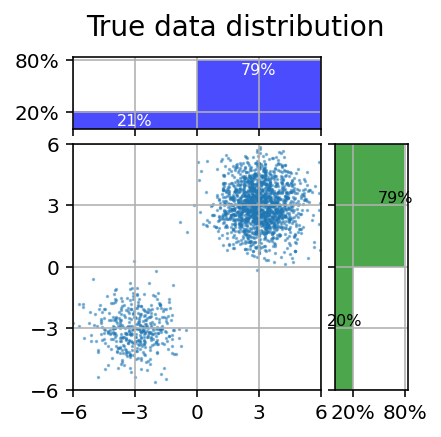

In [26]:
gen_data = np.load(f'{os.getcwd()}/chkpts/UnbalancedGaussian2D_200000_mse_Gaussian_0/gen_dataset.npy')
plot_hist(gen_data, 'Denoising score matching', 'generate_dsm.png')
gen_data = np.load(f'{os.getcwd()}/chkpts/UnbalancedGaussian2D_200000_rssm_Gaussian_0/gen_dataset.npy')
plot_hist(gen_data, 'RSSM with Gaussian sample', 'generate_gaussian.png', is_rssm=True)
gen_data = np.load(f'{os.getcwd()}/chkpts/UnbalancedGaussian2D_200000_rssm_uniform_4/gen_dataset.npy')
plot_hist(gen_data, 'RSSM with Uniform sample', 'generate_uniform.png', is_rssm=True) 
plot_hist(gen_data_langevin, 'Langevin Dynamics', 'generate_langevin.png')
plot_hist(true_data, 'True data distribution', 'data.png', original_data=True)

 Some demo figs

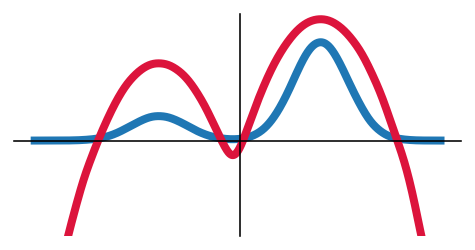

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generate sample data
# np.random.seed(42)
# data = np.random.normal(loc=0, scale=1, size=1000)  # Normal distribution
data = true_data[:, 0]

# Perform KDE estimation
kde = gaussian_kde(data)

# Generate evaluation points
x_eval = np.linspace(min(data), max(data), 1000)
density = kde(x_eval)
plt.figure(figsize=(4,2))
# Plot density estimation
plt.plot(x_eval, density, label='KDE Density', linewidth=4.0)
plt.plot(x_eval, 0.1 * (np.log(density)+5 ), label='KDE Density', linewidth=4.0, color='crimson')
# plt.hist(data, bins=30, density=True, alpha=0.5, label='Histogram')
# plt.legend()
# plt.xlabel('Value')
# plt.ylabel('Density')
# plt.title('1D Kernel Density Estimation')
ax = plt.gca()
# Hide all tick labels
ax.set_xticks([])
ax.set_yticks([])

# Add arrowed axes
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# Add arrows to axes
arrow_params = dict(arrowstyle='->', color='black', linewidth=1.5)
# ax.annotate('', xy=(10, 0), xytext=(0, 0), arrowprops=arrow_params)  # X-axis arrow
# ax.annotate('', xy=(0, 2), xytext=(0, 0), arrowprops=arrow_params)  # Y-axis arrow

# Set aspect ratio and limits
# ax.set_xlim(-10, 10)
ax.set_ylim(-0.3, 0.4)
plt.savefig('demo.pdf', transparent=True)


In [78]:
from scipy.stats import gaussian_kde
def get_one_d_kde(data, ax1, ax2, c):
    data = data[:, 0]

    # Perform KDE estimation
    kde = gaussian_kde(data)

    # Generate evaluation points
    x_eval = np.linspace(min(data), max(data), 1000)
    density = kde(x_eval)

    # Plot density estimation
    ax1.plot(x_eval, density, label='KDE Density', linewidth=4.0,color=c)
    # plt.plot(x_eval, density/4, label='KDE Density', linewidth=4.0, color='red')
    ax2.hist(data, bins=30, density=True, alpha=0.5, label='Histogram',color=c)
    # plt.legend()
    # plt.xlabel('Value')
    # plt.ylabel('Density')
    # plt.title('1D Kernel Density Estimation')
    # ax = plt.gca()
    # Hide all tick labels
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax2.set_xticks([])
    ax2.set_yticks([])

    # Add arrowed axes
    ax1.spines['left'].set_position('zero')
    ax1.spines['bottom'].set_position('zero')
    ax1.spines['left'].set_color('black')
    ax1.spines['bottom'].set_color('black')

    ax1.spines['right'].set_color('none')
    ax1.spines['top'].set_color('none')

    # Add arrows to axes
    arrow_params = dict(arrowstyle='->', color='black', linewidth=1.5)
    # ax.annotate('', xy=(10, 0), xytext=(0, 0), arrowprops=arrow_params)  # X-axis arrow
    # ax.annotate('', xy=(0, 2), xytext=(0, 0), arrowprops=arrow_params)  # Y-axis arrow

    # Set aspect ratio and limits
    # ax.set_xlim(-10, 10)
    # ax.set_ylim(-0.5, 2.5)
    # plt.savefig('demo.pdf')


In [38]:
model = Decoder(2, 128, 3)
chkpt_path = '/home/haitong/PycharmProjects/diffusion-model-hallucination/gaussian_experiments/chkpts/UnbalancedGaussian2D_200000_rssm_uniform_0/ddpm_UnbalancedGaussian2D_gen_0.pt'
chkpt = torch.load(chkpt_path, map_location=torch.device('cpu'))
model.load_state_dict(chkpt["model"])
trainloader = DataStreamer("UnbalancedGaussian2D", batch_size=10000, num_batches=2, modes=2)
evaluator = Evaluator(
    true_data=np.concatenate([
        next(iter(trainloader)) for _ in range(2)
    ]), eval_batch_size=1000, max_eval_count=2000, value_range=[-6, 6])

betas = get_beta_schedule(
    "linear", beta_start=0.001, beta_end=0.3, timesteps=20)

diffusion = GaussianDiffusion(
    betas=betas, model_mean_type="eps", model_var_type="fixed-large", loss_type="mse")


# def denoise_fn(x_t, t):
#     return diffusion.get_true_score_unbalanced_gmm(x_t, t)


# def sample_fn(n):
#     shape = (n,) + (2,)
    
#     return sample.detach().cpu().numpy()

    # if evaluator is not None:


# eval_results = evaluator.eval(sample_fn)
# gen_data = eval_results['x_gen']
x_t, noise_copy, xt_all, pred_x0_all = diffusion.p_sample_save_all(
        denoise_fn=model, shape=(2000, 2), device="cpu", noise=None)
# plt.scatter(gen_data[:, 0], gen_data[:, 1])

Timesteps: 20


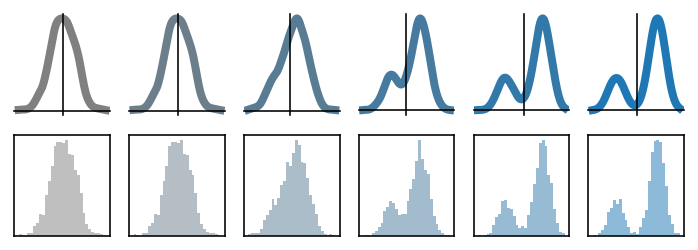

In [79]:
fig, axs = plt.subplots(2, 6, figsize=(6, 2))
get_one_d_kde(xt_all[0], axs[0, 0], axs[1, 0], cmap(0))
for i, xt in enumerate(xt_all[::4]):
    get_one_d_kde(xt, axs[0, i+1], axs[1, i+1],cmap(i+1))
plt.savefig('diffusion_demo.pdf')

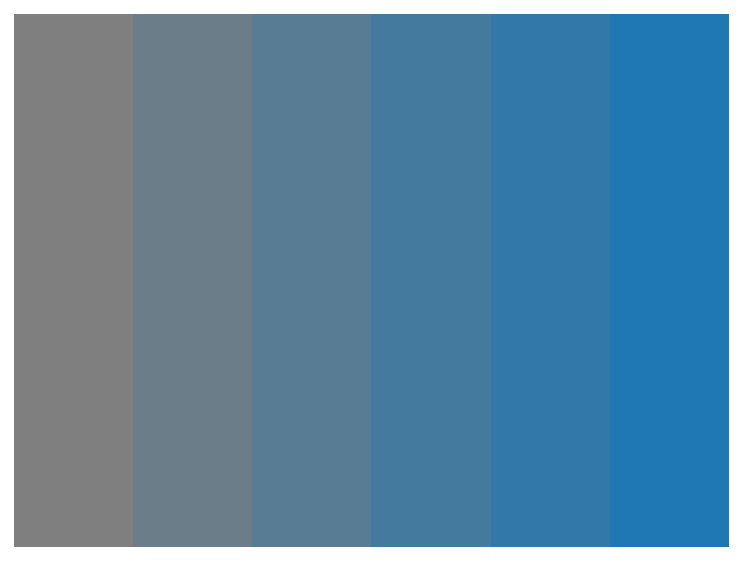

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def gray_to_blue_cmap(n=6):
    """Generate a colormap transitioning from gray to blue.
    
    Args:
        n (int): Number of colors in the colormap.
    
    Returns:
        LinearSegmentedColormap: A colormap object.
    """
    colors = [(0.5, 0.5, 0.5), (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
]  # Gray to Blue
    cmap = LinearSegmentedColormap.from_list("gray_to_blue", colors, N=n)
    return cmap

# Example usage:
cmap = gray_to_blue_cmap()
gradient = np.linspace(0, 1, 6).reshape(1, -1)

plt.imshow(gradient, aspect="auto", cmap=cmap)
plt.axis("off")
plt.show()


In [77]:
cmap(0)

(0.5, 0.5, 0.5, 1.0)